# 01 — Modelado Temporal (Fase 2A)

Transformamos el historial clínico en una **representación matemática de la evolución**. Para cada paciente se construyen las series Peso(t), IMC(t), Glucosa(t), PA sistólica(t), PA diastólica(t) y Riesgo(t).

> Los datos provienen de una **cohorte longitudinal sintética realista** (~400 pacientes × 12 meses, muestreo irregular, 5 arquetipos clínicos), alineada al esquema PREDIA (`Automonitoreo`, `MedicionAntropometrica`, `Prediccion`). El mismo pipeline opera sobre datos reales sin cambios.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


## Estructura temporal por paciente
Formato largo `[patient_id, fecha, variable, valor]`.

In [2]:
df = pd.read_csv(DS/'cohort_long.csv'); meta = pd.read_csv(DS/'cohort_meta.csv')
print('Filas:', len(df), '| pacientes:', df.patient_id.nunique())
print('Variables:', sorted(df.variable.unique()))
print('\nArquetipos:'); print(meta.archetype.value_counts())
df.head(8)

Filas: 75254 | pacientes: 400
Variables: ['actividad', 'glucosa', 'imc', 'pad', 'pas', 'peso', 'riesgo']

Arquetipos:
archetype
Estable                    116
Deterioro lento             91
Mejora rápida               74
Alto riesgo persistente     63
Oscilante                   56
Name: count, dtype: int64


,patient_id,archetype,fecha,t_days,variable,valor
0,1,Alto riesgo persistente,2025-01-02,1.0,glucosa,172.995
1,1,Alto riesgo persistente,2025-01-07,6.0,glucosa,189.210
2,1,Alto riesgo persistente,2025-01-11,10.0,glucosa,175.998
3,1,Alto riesgo persistente,2025-01-18,17.0,glucosa,188.748
4,1,Alto riesgo persistente,2025-01-27,26.0,glucosa,181.477
5,1,Alto riesgo persistente,2025-02-04,34.0,glucosa,175.493
6,1,Alto riesgo persistente,2025-02-12,42.0,glucosa,172.549
7,1,Alto riesgo persistente,2025-02-20,50.0,glucosa,169.032


## Series por arquetipo
Cada arquetipo define una dinámica clínica distinta (tendencia + oscilación + ruido) con muestreo irregular.

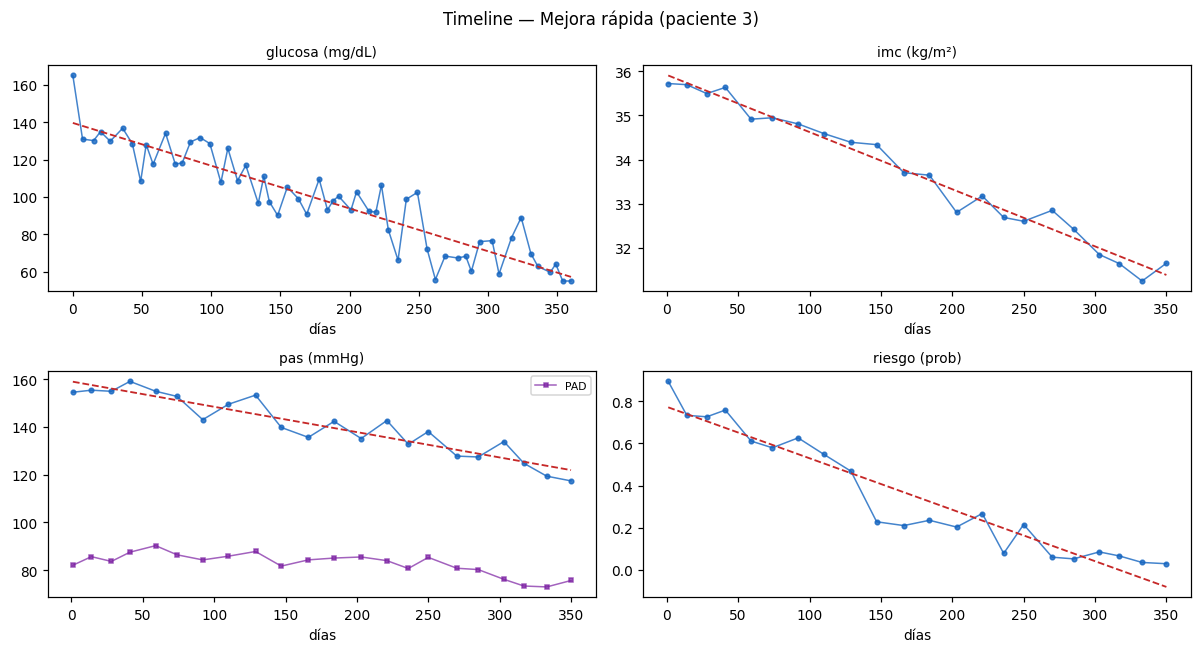

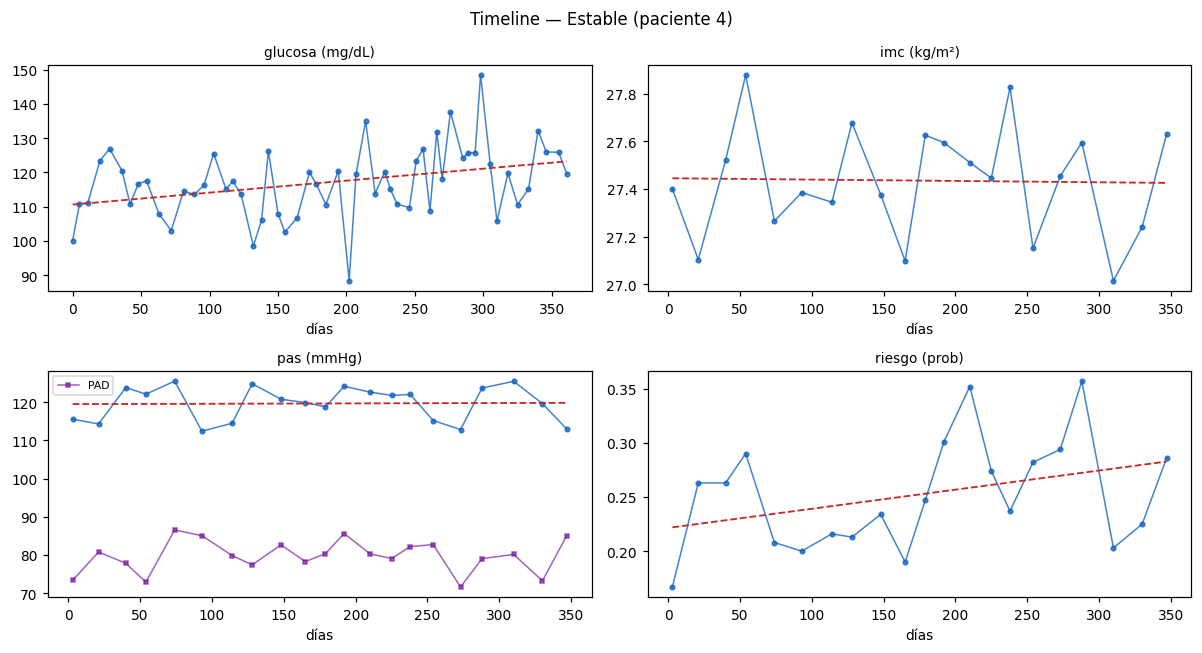

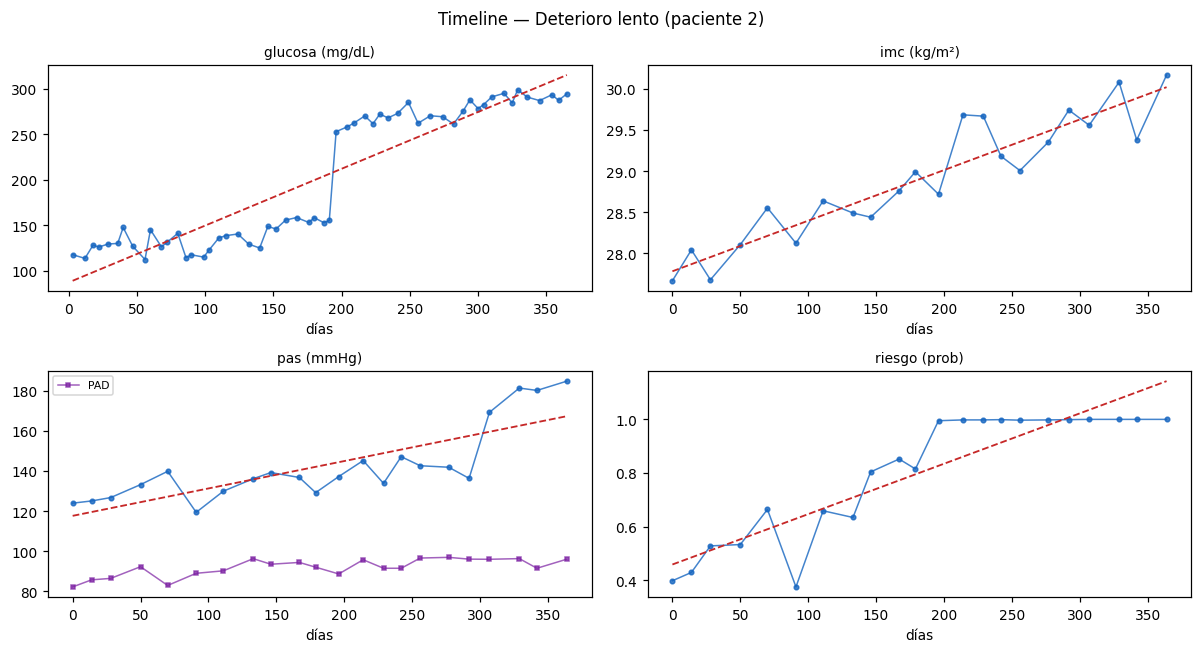

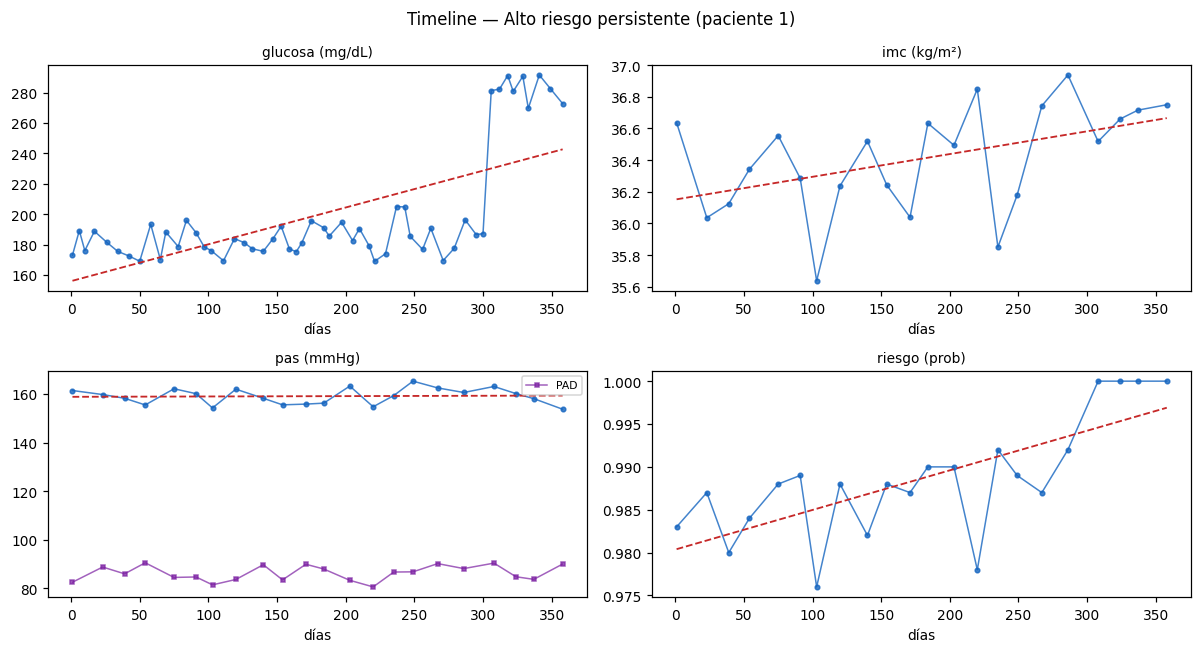

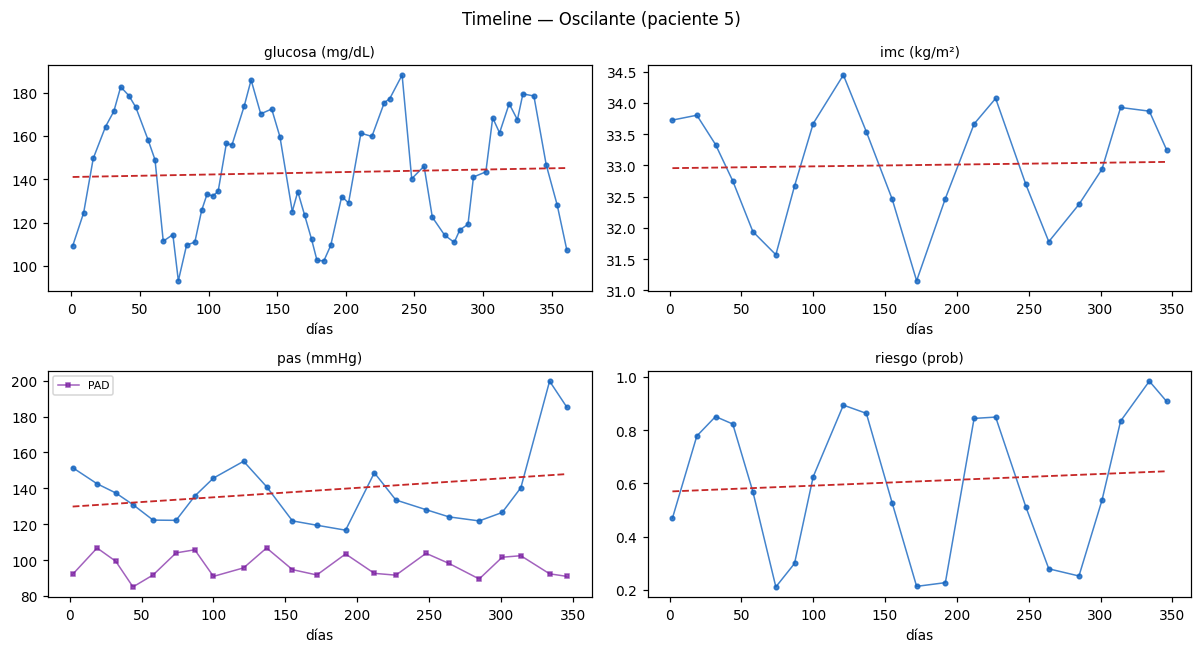

In [3]:
for a in config.ARCHETYPES:
    show(FIG/'cohort'/f"timeline_{a.replace(' ','_')}.png")

### Conclusión 2A
La información histórica queda representada como series de tiempo irregulares por variable y paciente — base de todo el análisis temporal.